# mục này là load data crema-d

In [ ]:
!pip install kagglehub


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tranlong0814","key":"a12e7bc7b2f177e577dc431a7226a6c1"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:

import os
import kagglehub

path = kagglehub.dataset_download("akaiinu/crema-d")
print("Path downloaded:", path)

# Kiểm tra xem trong path có gì
print(os.listdir(path))


Using Colab cache for faster access to the 'crema-d' dataset.
Path downloaded: /kaggle/input/crema-d
['cremad']


In [ ]:
!kaggle datasets download -d akaiinu/crema-d
!unzip -q crema-d.zip -d ./crema-d


Dataset URL: https://www.kaggle.com/datasets/akaiinu/crema-d
License(s): MIT
 98% 1.12G/1.14G [00:07<00:00, 139MB/s]
100% 1.14G/1.14G [00:09<00:00, 135MB/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
root_dir = "./crema-d/cremad/Image-01-FPS"


In [ ]:
import os, glob, pandas as pd

rows = []
for folder in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder)
    if not os.path.isdir(folder_path):
        continue

    # tách nhãn cảm xúc
    parts = folder.split("_")
    if len(parts) < 3:
        continue
    emotion = parts[2]  # ANG, DIS, FEA, HAP, NEU, SAD

    for img_path in glob.glob(os.path.join(folder_path, "*.jpg")):
        rows.append([img_path, emotion])

df = pd.DataFrame(rows, columns=["image_path", "emotion"])
df = df[df['emotion'].isin(['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD'])]  # 6 nhãn chính
print("Số lượng ảnh:", len(df))
print("Các nhãn:", sorted(df["emotion"].unique()))
df.head()


Số lượng ảnh: 23299
Các nhãn: ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']


,image_path,emotion
0,./crema-d/cremad/Image-01-FPS/1051_DFA_FEA_XX/...,FEA
1,./crema-d/cremad/Image-01-FPS/1051_DFA_FEA_XX/...,FEA
2,./crema-d/cremad/Image-01-FPS/1051_DFA_FEA_XX/...,FEA
3,./crema-d/cremad/Image-01-FPS/1063_TSI_HAP_XX/...,HAP
4,./crema-d/cremad/Image-01-FPS/1063_TSI_HAP_XX/...,HAP


In [ ]:
# Import libraries
import os,cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pylab import rcParams
rcParams['figure.figsize'] = 40, 40
import random

In [ ]:
from google.colab import drive
import shutil

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Đường dẫn muốn lưu trên Drive
drive_path = '/content/drive/MyDrive/CREMA-D'  # bạn có thể đổi tên thư mục

# 3. Copy toàn bộ thư mục CREMA-D vào Drive
shutil.copytree('./crema-d', drive_path)

print("Đã lưu xong vào Drive:", drive_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/CREMA-D'

In [ ]:

emotions = sorted(df["emotion"].unique())
emo2idx = {emo: i for i, emo in enumerate(emotions)}
df["label"] = df["emotion"].map(emo2idx)
print(emo2idx)


{'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

# Map nhãn
emotion_to_label = {'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}

# Transform ảnh
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # chuẩn ImageNet
                         std=[0.229, 0.224, 0.225])
])

# Dataset
class CREMADataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']
        label = emotion_to_label[row['emotion']]

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, label

# Split train/test
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['emotion'], random_state=42)

train_dataset = CREMADataset(train_df, transform=transform)
test_dataset = CREMADataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")


Train samples: 18639, Test samples: 4660


#Trích xuất feature từu resnet18

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class ResNet18Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights="IMAGENET1K_V1")

        # Freeze all
        for p in resnet.parameters():
            p.requires_grad = False

        # Unfreeze last 2 blocks
        for name, p in resnet.named_parameters():
            if "layer3" in name or "layer4" in name:
                p.requires_grad = True

        # Remove FC
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  # (B,512,1,1)
        self.proj = nn.Linear(512, 128)

    def forward(self, x):
        """
        x: (B, T, 3, 224, 224)
        """
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)

        feats = self.backbone(x)          # (B*T,512,1,1)
        feats = feats.view(B*T, 512)
        feats = self.proj(feats)          # (B*T,128)

        return feats.view(B, T, 128)      # (B,T,128)


In [ ]:
class TemporalAttentionFusion(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        """
        x: (B, T, 128)
        """
        w = self.attn(x)                  # (B,T,1)
        w = torch.softmax(w, dim=1)
        return (x * w).sum(dim=1)         # (B,128)


In [ ]:
class ImageEmotionFeatureModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ResNet18Encoder()
        self.fusion = TemporalAttentionFusion()

    def forward(self, frames):
        """
        frames: (B,T,3,224,224)
        """
        tokens = self.encoder(frames)     # (B,T,128)
        fused = self.fusion(tokens)       # (B,128)
        return fused


In [ ]:
# class TempClassifier(nn.Module):
#     def __init__(self, feature_dim=128, num_classes=6):
#         super().__init__()
#         self.fc = nn.Linear(feature_dim, num_classes)

#     def forward(self, x):
#         return self.fc(x)


In [ ]:
frames, labels = next(iter(train_loader))
print(frames.shape)


torch.Size([16, 3, 224, 224])


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

feature_model = ImageEmotionFeatureModel().to(device)
# temp_clf = TempClassifier(num_classes=6).to(device)
num_classes = 6
proxy_head = nn.Linear(128, num_classes).to(device)
criterion = nn.CrossEntropyLoss()

# optimizer = torch.optim.AdamW(
#     filter(lambda p: p.requires_grad,
#            list(feature_model.parameters()) + list(temp_clf.parameters())),
#     lr=1e-4
# )

optimizer = torch.optim.AdamW(
    list(filter(lambda p: p.requires_grad, feature_model.parameters())) +
    list(proxy_head.parameters()),
    lr=1e-4
)


epochs = 20   # hoặc 20, 30 tùy bạn

for epoch in range(epochs):
    feature_model.train()
    # temp_clf.train()
    proxy_head.train()

    for frames, labels in train_loader:
        frames, labels = frames.to(device), labels.to(device)

        # feats = feature_model(frames)      # (B,128)
        # frames: (B,3,224,224)
        frames = frames.unsqueeze(1).repeat(1, 3, 1, 1, 1)  # (B,3,3,224,224)
        feats = feature_model(frames)

        # logits = temp_clf(feats)
        logits = proxy_head(feats)

        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} done")


Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done
Epoch 6 done
Epoch 7 done
Epoch 8 done
Epoch 9 done
Epoch 10 done
Epoch 11 done
Epoch 12 done
Epoch 13 done
Epoch 14 done
Epoch 15 done
Epoch 16 done
Epoch 17 done
Epoch 18 done
Epoch 19 done
Epoch 20 done


In [ ]:
del proxy_head


In [ ]:
def extract_features(model, loader):
    model.eval()
    feats, labels = [], []

    with torch.no_grad():
        for frames, labs in loader:
            frames = frames.to(device)

            # frames: (B,3,224,224) → (B,3,3,224,224)
            frames = frames.unsqueeze(1).repeat(1, 3, 1, 1, 1)

            f = model(frames)  # (B,128)

            feats.append(f.cpu().numpy())
            labels.append(labs.numpy())

    return np.concatenate(feats), np.concatenate(labels)


In [ ]:
train_features, train_labels = extract_features(feature_model, train_loader)


In [ ]:
test_features, test_labels = extract_features(feature_model, test_loader)



In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import normalize

train_features = normalize(train_features)
test_features = normalize(test_features)

svm = SVC(kernel="rbf", C=10, gamma="scale")
svm.fit(train_features, train_labels)

pred = svm.predict(test_features)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(test_labels, pred))
print(confusion_matrix(test_labels, pred))


              precision    recall  f1-score   support

           0       0.63      0.61      0.62       806
           1       0.73      0.74      0.73       868
           2       0.62      0.66      0.64       785
           3       0.78      0.77      0.77       739
           4       0.67      0.68      0.68       653
           5       0.61      0.59      0.60       809

    accuracy                           0.67      4660
   macro avg       0.67      0.67      0.67      4660
weighted avg       0.67      0.67      0.67      4660

[[495  58  89  36  45  83]
 [ 49 639  84  15  20  61]
 [ 70  77 516  22  27  73]
 [ 50  18   9 566  62  34]
 [ 36  30  39  51 444  53]
 [ 84  56  90  37  62 480]]


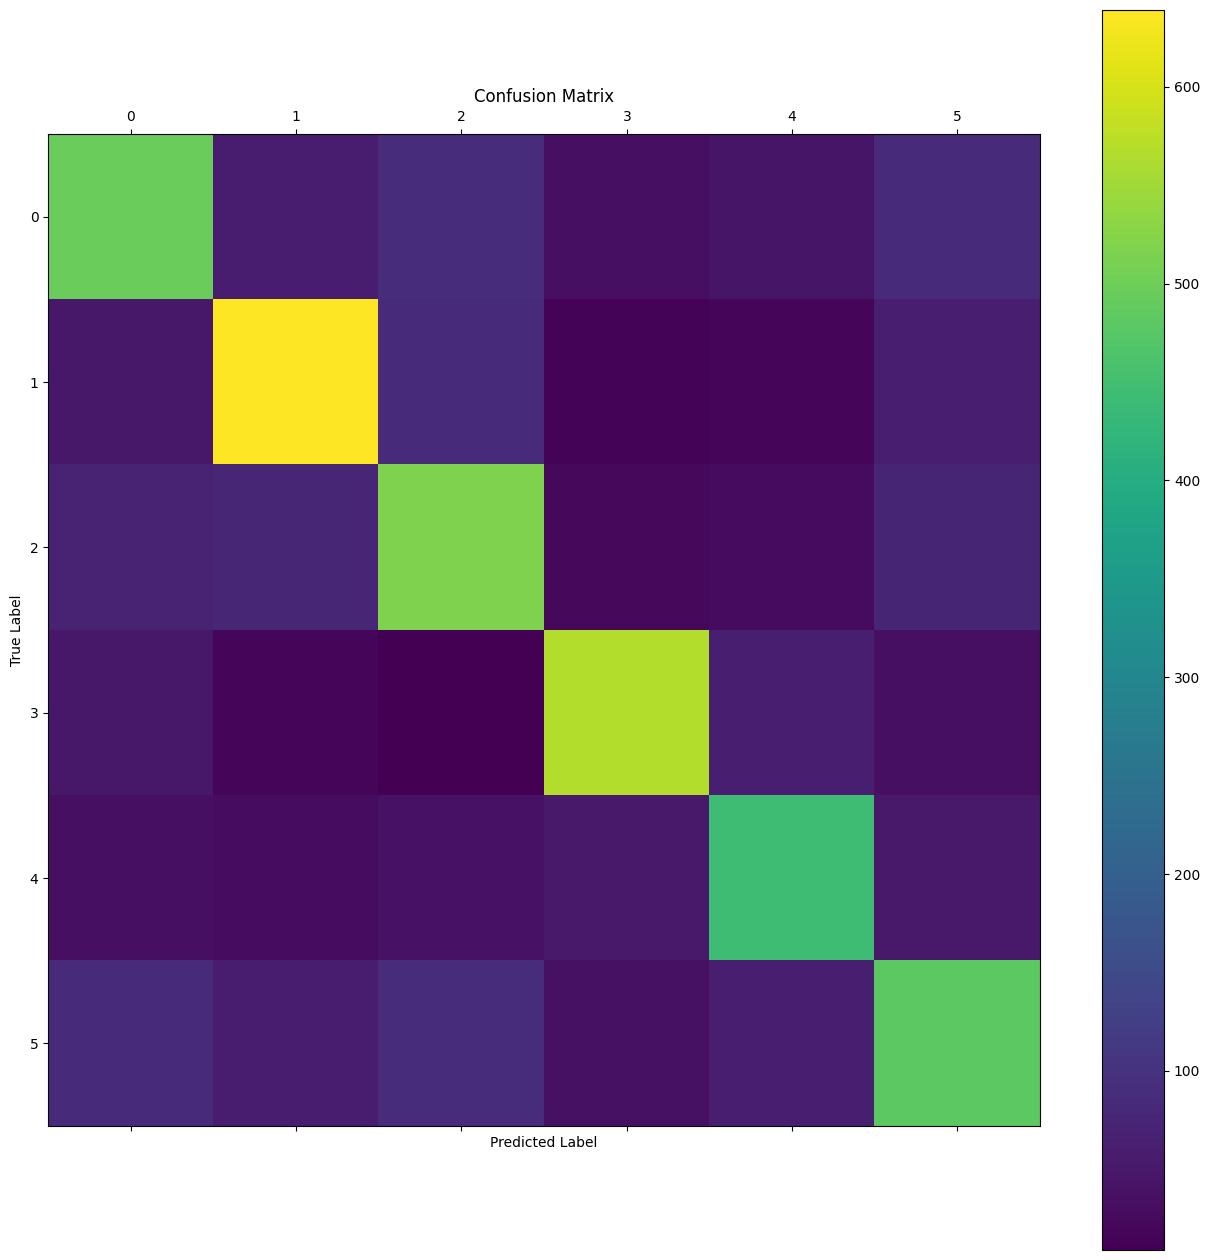

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, pred)
plt.matshow(cm)
plt.title('Confusion Matrix')
plt.colorbar()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


#Training SVM on ResNet18 features

PHẦN 1 — LẤY TẤT CẢ ẢNH VÀ NHÃN TỪ test_loader

PHẦN 2 — CHỌN NGẪU NHIÊN ẢNH VÀ HIỂN THỊ DỰ ĐOÁN

In [ ]:
class TemporalResNet18(nn.Module):
    def __init__(self, T=3):
        super().__init__()
        self.T = T

        backbone = models.resnet18(pretrained=True)

        # Remove FC
        self.cnn = nn.Sequential(*list(backbone.children())[:-1])  # 512
        self.proj = nn.Linear(512, 128)

        # Freeze early layers
        for name, p in backbone.named_parameters():
            if not ("layer3" in name or "layer4" in name):
                p.requires_grad = False

    def forward(self, x):
        # x: (B,3,224,224)
        x = x.unsqueeze(1).repeat(1, self.T, 1, 1, 1)   # (B,T,3,224,224)
        B, T, C, H, W = x.shape

        x = x.view(B*T, C, H, W)
        f = self.cnn(x).squeeze(-1).squeeze(-1)        # (B*T,512)
        f = self.proj(f)                               # (B*T,128)

        f = f.view(B, T, 128).mean(dim=1)               # temporal fusion
        return f                                       # (B,128)


In [ ]:
def extract_features(model, loader, device):
    model.eval()
    feats, labels = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            f = model(imgs)          # (B,128)
            feats.append(f.cpu())
            labels.append(lbls)

    return torch.cat(feats).numpy(), torch.cat(labels).numpy()


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TemporalResNet18(T=3).to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
train_features, train_labels = extract_features(model, train_loader, device)
test_features, test_labels   = extract_features(model, test_loader, device)


🎯 PHẦN 3 — TỰ ĐỘNG TÍNH C VÀ GAMMA

In [ ]:
from sklearn.metrics import pairwise_distances

def auto_gamma(X, sample_size=2000):
    n = min(sample_size, len(X))
    idx = np.random.choice(len(X), n, replace=False)
    X_sub = X[idx]
    dists = pairwise_distances(X_sub, X_sub)
    median_dist = np.median(dists)
    return 1 / (2 * median_dist ** 2)

def auto_C(X):
    return 1 / np.mean(np.var(X, axis=0))

C, gamma = auto_C(train_features), auto_gamma(train_features)


In [ ]:
from sklearn.svm import SVC
best_SVM = SVC(C=C, gamma=gamma)
best_SVM.fit(train_features, train_labels)
predicted = best_SVM.predict(test_features)


In [ ]:
from sklearn import metrics

print(metrics.classification_report(test_labels, predicted))


              precision    recall  f1-score   support

           0       0.43      0.48      0.45       806
           1       0.63      0.62      0.63       868
           2       0.47      0.49      0.48       785
           3       0.64      0.56      0.59       739
           4       0.49      0.49      0.49       653
           5       0.41      0.42      0.41       809

    accuracy                           0.51      4660
   macro avg       0.51      0.51      0.51      4660
weighted avg       0.51      0.51      0.51      4660



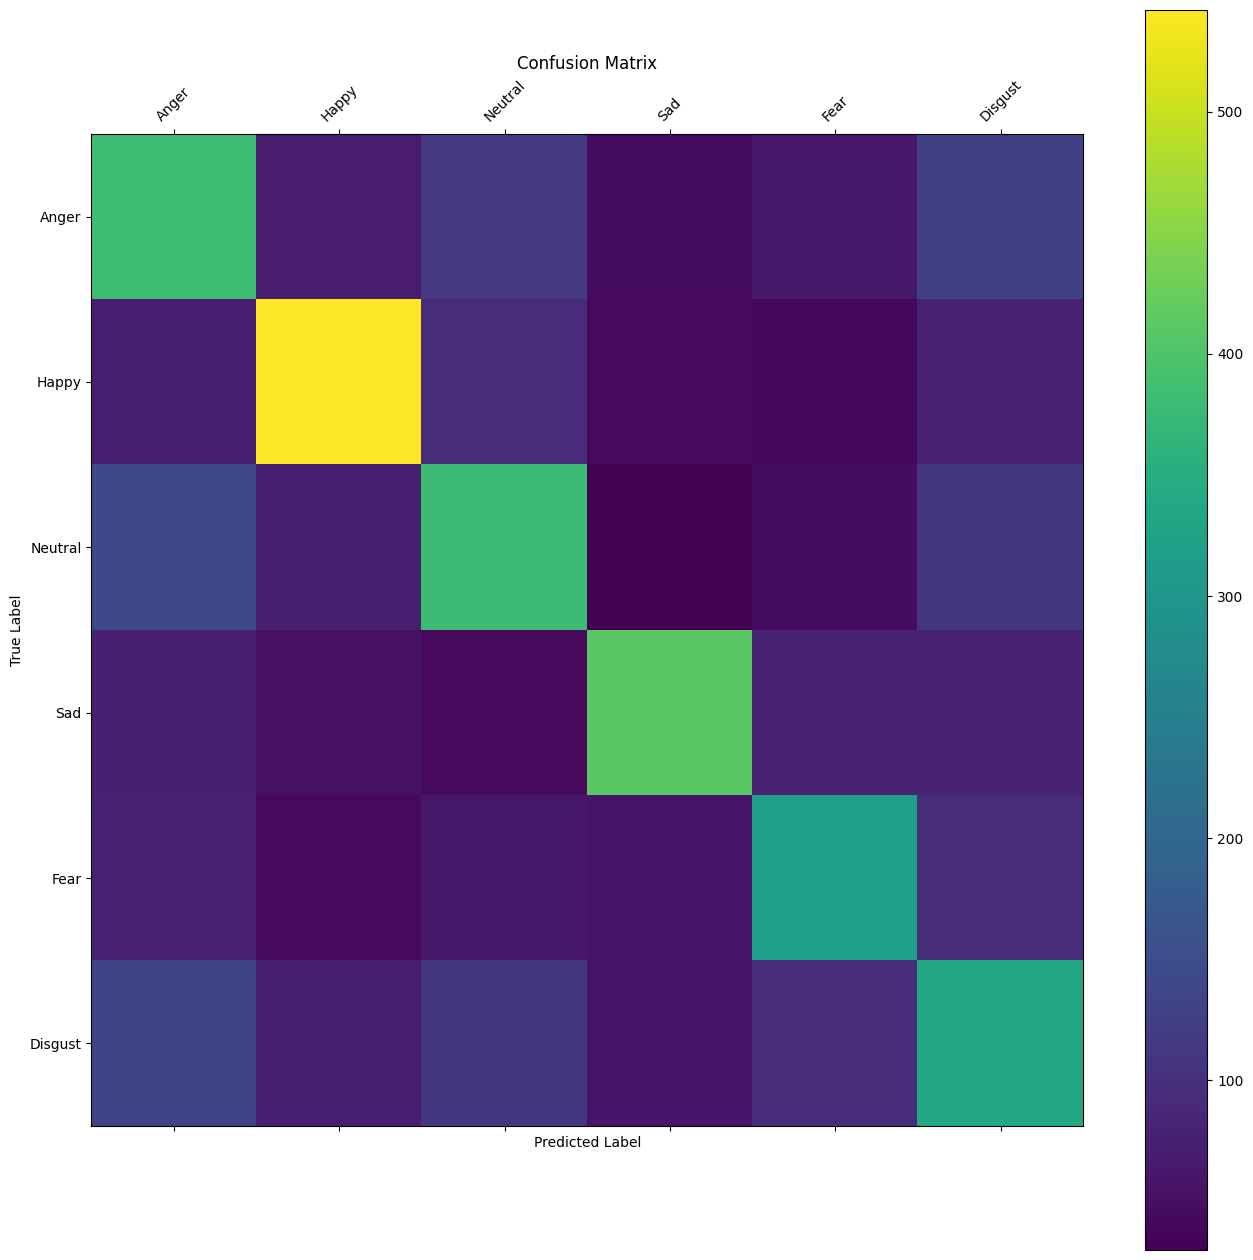

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, predicted)

plt.matshow(cm)
plt.title('Confusion Matrix')
plt.colorbar()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

emotion_names = ["Anger","Happy","Neutral","Sad","Fear","Disgust"]
plt.xticks(range(6), emotion_names, rotation=45)
plt.yticks(range(6), emotion_names)
plt.show()


# Hiển thị ảnh test + dự đoán SVM

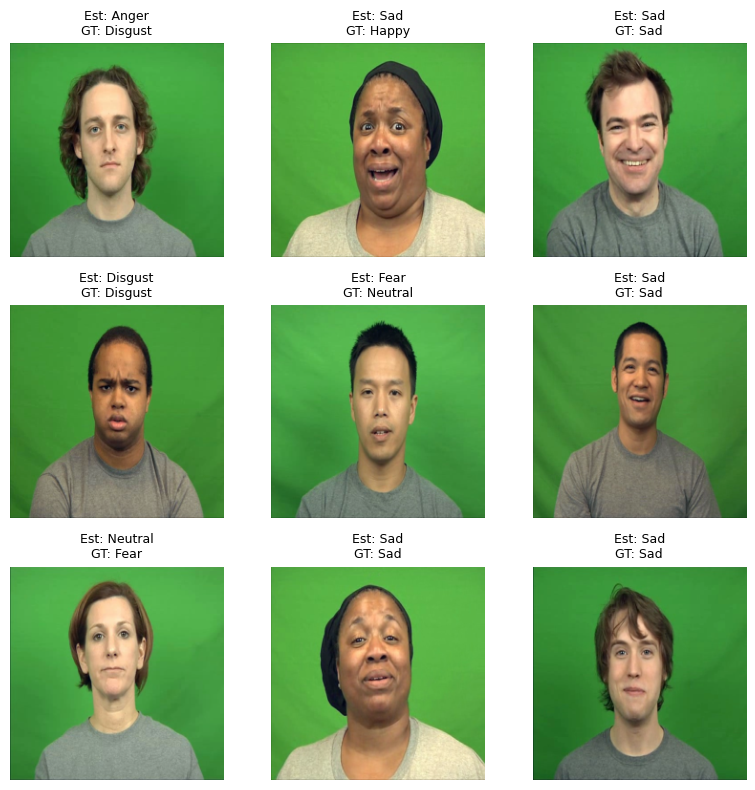

In [ ]:
import random

int_to_emotion = {0:"Anger",1:"Happy",2:"Neutral",3:"Sad",4:"Fear",5:"Disgust"}

N = 3
fig, axs = plt.subplots(N, N, figsize=(8, 8))

for i in range(N):
    for j in range(N):
        idx = random.randint(0, len(test_dataset)-1)
        img_tensor, gt = test_dataset[idx]

        img = img_tensor.permute(1,2,0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        pred = predicted[idx]

        axs[i,j].imshow(img)
        axs[i,j].set_title(
            f"Est: {int_to_emotion[pred]}\nGT: {int_to_emotion[gt]}",
            fontsize=9
        )
        axs[i,j].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
print(type(test_dataset))
print(type(test_dataset[0]))
print(test_dataset[0])


<class '__main__.CREMADataset'>
<class 'tuple'>
(tensor([[[-0.9705, -0.7993, -0.8164,  ..., -0.7650, -0.7650, -0.7650],
         [-0.7308, -0.5596, -0.5767,  ..., -0.4911, -0.4911, -0.4911],
         [-0.7650, -0.5938, -0.6109,  ..., -0.5082, -0.5082, -0.5082],
         ...,
         [-1.0390, -0.9020, -0.9020,  ..., -0.9020, -0.9020, -0.9020],
         [-1.0219, -0.8849, -0.8849,  ..., -0.8849, -0.8849, -0.8849],
         [-1.2103, -1.0733, -1.0733,  ..., -1.0733, -1.0733, -1.0733]],

        [[ 0.2927,  0.4678,  0.4503,  ...,  0.5553,  0.5553,  0.5553],
         [ 0.5378,  0.7129,  0.6954,  ...,  0.8354,  0.8354,  0.8354],
         [ 0.5203,  0.6954,  0.6779,  ...,  0.8354,  0.8354,  0.8354],
         ...,
         [ 0.0301,  0.1702,  0.1702,  ...,  0.2052,  0.2052,  0.2052],
         [ 0.0301,  0.1702,  0.1527,  ...,  0.2052,  0.2052,  0.2052],
         [-0.1975, -0.0574, -0.0574,  ...,  0.0126,  0.0126,  0.0126]],

        [[-1.2293, -1.0550, -1.0724,  ..., -1.0724, -1.0724, -1.072

#CELL 1 — Khởi tạo MLPClassifier

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    alpha=1e-4,              # L2 regularization
    batch_size=64,
    learning_rate='adaptive',
    max_iter=300,
    random_state=42,
    verbose=True
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(train_features)
X_test  = scaler.transform(test_features)

mlp.fit(X_train, train_labels)
predicted = mlp.predict(X_test)


Iteration 1, loss = 1.67075495
Iteration 2, loss = 1.50522371
Iteration 3, loss = 1.41135357
Iteration 4, loss = 1.33818585
Iteration 5, loss = 1.26769730
Iteration 6, loss = 1.21676432
Iteration 7, loss = 1.15656460
Iteration 8, loss = 1.10635167
Iteration 9, loss = 1.05610975
Iteration 10, loss = 1.00707258
Iteration 11, loss = 0.96678641
Iteration 12, loss = 0.92284729
Iteration 13, loss = 0.87694667
Iteration 14, loss = 0.84925663
Iteration 15, loss = 0.80581043
Iteration 16, loss = 0.77253919
Iteration 17, loss = 0.73830029
Iteration 18, loss = 0.71080696
Iteration 19, loss = 0.67382957
Iteration 20, loss = 0.64741159
Iteration 21, loss = 0.62045271
Iteration 22, loss = 0.59693655
Iteration 23, loss = 0.56523809
Iteration 24, loss = 0.54552874
Iteration 25, loss = 0.52670987
Iteration 26, loss = 0.49544502
Iteration 27, loss = 0.48423703
Iteration 28, loss = 0.45238842
Iteration 29, loss = 0.43419938
Iteration 30, loss = 0.43124190
Iteration 31, loss = 0.40425651
Iteration 32, los

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(test_labels, predicted)
print("Accuracy:", acc)


Accuracy: 0.21094420600858368


CELL 2 — In accuracy + classification report

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

predicted = mlp.predict(test_features)

print("Accuracy:", accuracy_score(test_labels, predicted))
print(classification_report(test_labels, predicted))


Accuracy: 0.21094420600858368
              precision    recall  f1-score   support

           0       0.19      0.40      0.25       806
           1       0.28      0.07      0.11       868
           2       0.31      0.14      0.19       785
           3       0.23      0.32      0.27       739
           4       0.16      0.02      0.04       653
           5       0.19      0.29      0.23       809

    accuracy                           0.21      4660
   macro avg       0.23      0.21      0.18      4660
weighted avg       0.23      0.21      0.19      4660



In [ ]:
# mlp_classifier.fit(train_features, train_labels)
predicted = mlp.predict(test_features)


In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (mlp, metrics.classification_report(test_labels, predicted)))

Classification report for classifier MLPClassifier(batch_size=64, hidden_layer_sizes=(256, 128),
              learning_rate='adaptive', max_iter=300, random_state=42,
              verbose=True):
              precision    recall  f1-score   support

           0       0.19      0.40      0.25       806
           1       0.28      0.07      0.11       868
           2       0.31      0.14      0.19       785
           3       0.23      0.32      0.27       739
           4       0.16      0.02      0.04       653
           5       0.19      0.29      0.23       809

    accuracy                           0.21      4660
   macro avg       0.23      0.21      0.18      4660
weighted avg       0.23      0.21      0.19      4660




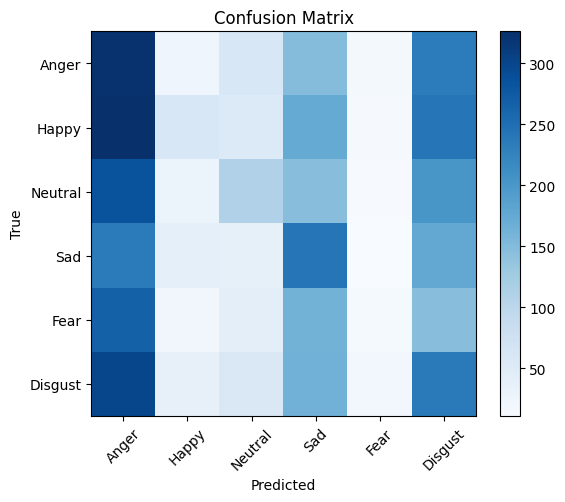

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(test_labels, predicted)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

emotion_names = ["Anger","Happy","Neutral","Sad","Fear","Disgust"]
plt.xticks(range(6), emotion_names, rotation=45)
plt.yticks(range(6), emotion_names)

plt.tight_layout()
plt.show()


In [ ]:
test_images = []
test_labels_list = []

for imgs, lbls in test_loader:
    for img, lbl in zip(imgs, lbls):
        test_images.append(img)       # ảnh tensor C×H×W
        test_labels_list.append(lbl)  # label


#CELL 3 — Hiển thị lại ảnh test với label predict

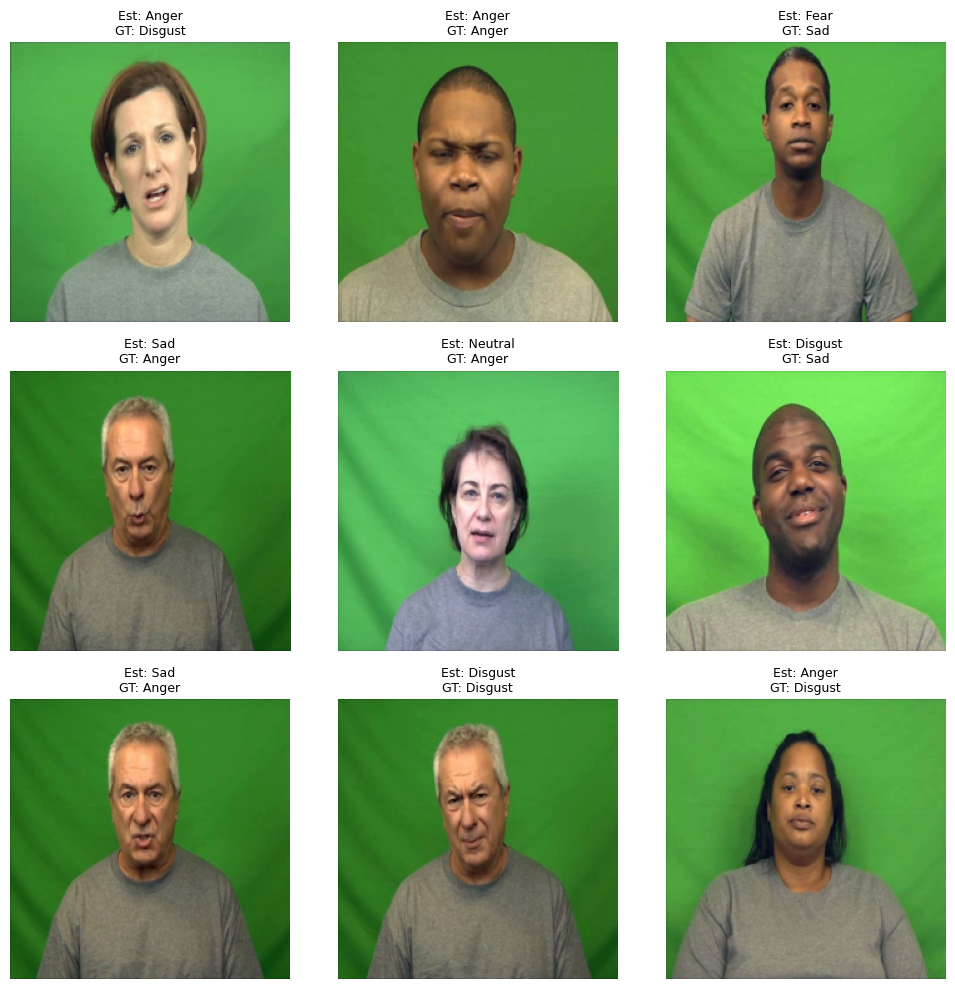

In [ ]:
import random

int_to_emotion = {0:"Anger",1:"Happy",2:"Neutral",3:"Sad",4:"Fear",5:"Disgust"}

N = 3
fig, axs = plt.subplots(N, N, figsize=(10, 10))

for i in range(N):
    for j in range(N):
        idx = random.randint(0, len(test_images)-1)

        img = test_images[idx].permute(1,2,0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min())

        gt = int(test_labels_list[idx])
        pred = predicted[idx]

        axs[i,j].imshow(img)
        axs[i,j].set_title(
            f"Est: {int_to_emotion[pred]}\nGT: {int_to_emotion[gt]}",
            fontsize=9
        )
        axs[i,j].axis("off")

plt.tight_layout()
plt.show()
